# Historical Realism Verification (`convoy_layout_1`)

This notebook is focused on realism verification only (not optimization comparison):
- moving vs static U-boat
- torpedo launch geometry + hit outcomes
- MP4/frames + snapshot checks
- pass/fail assertions


In [1]:
# Imports
from __future__ import annotations

import importlib.util
import json
import shutil
from collections import Counter
from dataclasses import replace
from pathlib import Path

import numpy as np

from convoy_sim.attack_profiles import DEFAULT_ATTACK_PROFILE_LIBRARY
from convoy_sim.dynamics import ConvoyFormation, ConvoyKinematics, RouteLeg, RoutePlan, ZigZagPlan
from convoy_sim.feasibility import Environment
from convoy_sim.geometry import as_vec
from convoy_sim.realism import UBoatLeg, UBoatMotionPlan
from convoy_sim.noise import NoiseModel
from convoy_sim.simulation import advance_dynamic_hit_state, init_dynamic_hit_state, apply_noise_to_torpedoes
from convoy_sim.viz_attack import render_attack_frame, save_attack_animation_mp4, save_attack_frames
from scenarios.convoy_profiles import get_convoy_layout_profile

try:
    from IPython.display import Video, display
except Exception:
    Video = None
    display = None


In [2]:
# --- Config ---
REPO = Path('/Users/matthewplambeck/Desktop/Convoy Layout Project')
OUTPUT_ROOT = REPO / 'notebooks/results/attack_manual_verification'
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

# Keep verification scoped to convoy_layout_1
CONVOY_PROFILE = 'convoy_layout_1'
PROFILE_ID = 'P01'
SEED = 1942

SIM_DURATION_S = 180.0
FPS = 8
VIEW_BOUNDS = (-5000, 5000, -5000, 5000)

TRAIL_LENGTH_S = 600.0
TRAIL_LINEWIDTH = 0.20
TRAIL_ALPHA = 0.35

# Smaller in-scale U-boat marker
U_BOAT_MARKER_SIZE = 6.0

# Chill environment override for this notebook verification
ENV_CFG = {
    'time_of_day': 'day',
    'visibility_m': 6000.0,
    'sea_state': 1,
    'detection_risk_scale': 1.0,
}

# Keep noise realism sourced from baseline config
import tomllib
BASE_CFG = tomllib.loads((REPO / 'configs/baseline/default.toml').read_text(encoding='utf-8'))
NOISE_CFG = dict(BASE_CFG.get('simulation', {}).get('noise', {}))

print('OUTPUT_ROOT:', OUTPUT_ROOT)
print('CONVOY_PROFILE:', CONVOY_PROFILE)
print('PROFILE_ID:', PROFILE_ID)
print('SEED:', SEED)
print('ENV_CFG:', ENV_CFG)
print('NOISE_CFG:', NOISE_CFG)
print('matplotlib installed:', importlib.util.find_spec('matplotlib') is not None)
print('ffmpeg available:', shutil.which('ffmpeg') is not None)


OUTPUT_ROOT: /Users/matthewplambeck/Desktop/Convoy Layout Project/notebooks/results/attack_manual_verification
CONVOY_PROFILE: convoy_layout_1
PROFILE_ID: P01
SEED: 1942
ENV_CFG: {'time_of_day': 'day', 'visibility_m': 6000.0, 'sea_state': 1, 'detection_risk_scale': 1.0}
NOISE_CFG: {'sigma_heading_rad': 0.01, 'sigma_launch_delay': 0.05, 'sigma_speed_mps': 0.25, 'p_dud': 0.02}
matplotlib installed: True
ffmpeg available: True


In [3]:
# --- Build Scenarios + Print Hard Data ---
env = Environment(
    time_of_day=str(ENV_CFG['time_of_day']),
    visibility_m=float(ENV_CFG['visibility_m']),
    sea_state=int(ENV_CFG['sea_state']),
    detection_risk_scale=float(ENV_CFG['detection_risk_scale']),
)

layout_profile = get_convoy_layout_profile(CONVOY_PROFILE)
ships = layout_profile.build_ships()
class_counts = Counter([s.ship_class.value for s in ships])

profiles = {p.profile_id: p for p in DEFAULT_ATTACK_PROFILE_LIBRARY.profiles}
if PROFILE_ID not in profiles:
    raise ValueError(f'Unknown profile id: {PROFILE_ID}')

base_profile = profiles[PROFILE_ID]
moving_profile = replace(base_profile, u_boat_mode='moving')
static_profile = replace(base_profile, u_boat_mode='static')


def motion_plan_for(profile):
    legs = tuple(UBoatLeg(duration_s=float(a), heading_rad=float(b), speed_mps=float(c)) for a, b, c in profile.u_boat_motion_legs)
    return UBoatMotionPlan(
        initial_position=np.asarray(profile.u_pos, dtype=float),
        initial_heading_rad=float(profile.u_boat_initial_heading_rad),
        initial_speed_mps=float(profile.u_boat_initial_speed_mps),
        mode=str(profile.u_boat_mode),
        legs=legs,
        launch_time_s=float(profile.u_boat_launch_time_s),
        turn_rate_limit_rad_s=profile.u_boat_turn_rate_limit_rad_s,
        accel_limit_mps2=profile.u_boat_accel_limit_mps2,
    )


def scenario_data(profile):
    plan = motion_plan_for(profile)
    rng = np.random.default_rng(int(SEED))
    torpedoes = profile.build_torpedoes(rng, ships=ships, env=env)
    launch_state = plan.state_at(float(profile.u_boat_launch_time_s))
    return {
        'profile': profile,
        'plan': plan,
        'torpedoes': torpedoes,
        'start_pos': plan.position_at(0.0),
        'launch_pos': plan.position_at(float(profile.u_boat_launch_time_s)),
        'end_pos': plan.position_at(float(SIM_DURATION_S)),
        'launch_heading_rad': float(launch_state[1]),
    }


moving = scenario_data(moving_profile)
static = scenario_data(static_profile)

print('=== Convoy Stats ===')
print('name:', layout_profile.name)
print('description:', layout_profile.description)
print('layout_kwargs:', layout_profile.layout_kwargs)
print('ship_count:', len(ships))
print('class_counts:', dict(class_counts))

print()
print('=== Environment + Noise Used In This Notebook ===')
print('environment:', ENV_CFG)
print('noise:', NOISE_CFG)


def print_case(label, data):
    p = data['profile']
    print()
    print(f'=== {label} ===')
    print('profile_id:', p.profile_id)
    print('name:', p.name)
    print('attack_mode:', p.mode)
    print('u_boat_mode:', p.u_boat_mode)
    print('n_torpedoes:', p.n)
    print('torpedo_speed_mps:', p.speed)
    print('torpedo_max_run_time_s:', p.max_run_time)
    print('launch_delay_s:', p.launch_delay_s)
    print('salvo_interval_s:', p.salvo_interval_s)
    print('fan_base_bearing_rad:', p.base_bearing_rad)
    print('fan_spread_rad:', p.spread_rad)
    print('u_boat_initial_heading_rad:', p.u_boat_initial_heading_rad)
    print('u_boat_initial_speed_mps:', p.u_boat_initial_speed_mps)
    print('u_boat_launch_time_s:', p.u_boat_launch_time_s)
    print('u_boat_turn_rate_limit_rad_s:', p.u_boat_turn_rate_limit_rad_s)
    print('u_boat_accel_limit_mps2:', p.u_boat_accel_limit_mps2)
    print('u_boat_motion_legs:', p.u_boat_motion_legs)
    print('sub_length_m:', p.sub_length_m)
    print('sub_beam_m:', p.sub_beam_m)
    print('launch_from:', p.launch_from)
    print('max_bow_offset_deg:', p.max_bow_offset_deg)
    print('u_boat_heading_at_launch_rad:', data['launch_heading_rad'])
    print('u_boat_heading_at_launch_deg:', float(np.degrees(data['launch_heading_rad'])))
    print('start_pos:', data['start_pos'].tolist())
    print('launch_pos:', data['launch_pos'].tolist())
    print('end_pos:', data['end_pos'].tolist())
    print('dist_start_to_launch_m:', float(np.linalg.norm(data['launch_pos'] - data['start_pos'])))
    print('dist_start_to_end_m:', float(np.linalg.norm(data['end_pos'] - data['start_pos'])))
    print('torpedo_launches:')
    for t in data['torpedoes']:
        launch_deg = float(np.degrees(t.heading_rad))
        rel_rad = float(t.heading_rad - data['launch_heading_rad'])
        rel_deg = float(np.degrees(rel_rad))
        print(
            f"  {t.id}: launch_pos={np.asarray(t.launch_position).tolist()}, "
            f"heading_rad={float(t.heading_rad):.6f}, heading_deg={launch_deg:.3f}, "
            f"rel_to_sub_deg={rel_deg:.3f}, launch_delay_s={float(t.launch_delay):.3f}"
        )


print_case('MOVING', moving)
print_case('STATIC', static)


=== Convoy Stats ===
name: convoy_layout_1
description: Starting 7x6 convoy layout with all freighters.
layout_kwargs: {'n_rows': 6, 'n_cols': 7, 'spacing_along': 457.2, 'spacing_across': 1371.6, 'speed': 5.0, 'heading_rad': 0.0, 'length': 150.0, 'beam': 20.0, 'origin': array([0., 0.])}
ship_count: 42
class_counts: {'freighter': 42}

=== Environment + Noise Used In This Notebook ===
environment: {'time_of_day': 'day', 'visibility_m': 6000.0, 'sea_state': 1, 'detection_risk_scale': 1.0}
noise: {'sigma_heading_rad': 0.01, 'sigma_launch_delay': 0.05, 'sigma_speed_mps': 0.25, 'p_dud': 0.02}

=== MOVING ===
profile_id: P01
name: profile_01
attack_mode: fan
u_boat_mode: moving
n_torpedoes: 4
torpedo_speed_mps: 15.4333
torpedo_max_run_time_s: 486.0
launch_delay_s: 0.5
salvo_interval_s: 2.0
fan_base_bearing_rad: 4.04
fan_spread_rad: 0.0698
u_boat_initial_heading_rad: 0.0
u_boat_initial_speed_mps: 2.0
u_boat_launch_time_s: 0.0
u_boat_turn_rate_limit_rad_s: None
u_boat_accel_limit_mps2: None
u_b

In [4]:
# --- Render MP4/Frames + Snapshots (time-aware moving U-boat marker) ---
if importlib.util.find_spec('matplotlib') is None:
    raise RuntimeError('matplotlib is required for visuals in this notebook.')


def build_dynamics(ships_local):
    formation = ConvoyFormation(
        ships0=ships_local,
        convoy_origin0=as_vec(0.0, 0.0),
        convoy_heading0=0.0,
    )
    kin = ConvoyKinematics(
        route=RoutePlan(legs=[RouteLeg(duration_s=float(SIM_DURATION_S), heading_rad=0.0)]),
        zigzag=ZigZagPlan(enabled=False),
    )
    return formation, kin


def render_case(label, data):
    import matplotlib.pyplot as plt

    case_dir = OUTPUT_ROOT / label.lower()
    case_dir.mkdir(parents=True, exist_ok=True)

    ships_local = get_convoy_layout_profile(CONVOY_PROFILE).build_ships()
    formation, kin = build_dynamics(ships_local)

    common = dict(
        color_by='class',
        show_trails=True,
        trail_length_s=float(TRAIL_LENGTH_S),
        trail_linewidth=float(TRAIL_LINEWIDTH),
        trail_alpha=float(TRAIL_ALPHA),
        show_footprint=False,
        ship_marker='ship',
        rotate_by_heading=True,
        use_hull_dimensions=True,
        trail_color='red',
        legend_bbox_to_anchor=(0.5, -0.20),
        view_bounds=VIEW_BOUNDS,
        hide_spines=True,
        figure_facecolor='lightgrey',
        show_u_boat=True,
        u_boat_position_fn=lambda t: data['plan'].position_at(float(t)),
        u_boat_size=float(U_BOAT_MARKER_SIZE),
    )

    mp4_path = case_dir / f'{label.lower()}_{PROFILE_ID}.mp4'
    frames_dir = case_dir / 'frames'

    mp4_written = None
    try:
        save_attack_animation_mp4(
            str(mp4_path),
            ships_t0=ships_local,
            torpedoes=data['torpedoes'],
            t_start=0.0,
            t_end=float(SIM_DURATION_S),
            fps=int(FPS),
            dynamics=(formation, kin),
            **common,
        )
        mp4_written = mp4_path
    except Exception as exc:
        print(f'{label}: MP4 unavailable ({exc}); writing frames fallback...')
        save_attack_frames(
            str(frames_dir),
            ships_t0=ships_local,
            torpedoes=data['torpedoes'],
            t_start=0.0,
            t_end=float(SIM_DURATION_S),
            fps=int(FPS),
            dynamics=(formation, kin),
            **common,
        )

    # Snapshot frames
    times = [0.0, float(data['profile'].u_boat_launch_time_s), float(SIM_DURATION_S)]
    names = ['t0', 'tlaunch', 'tend']
    for t_val, name in zip(times, names):
        fig, ax = plt.subplots(figsize=(7, 7), facecolor='lightgrey')
        render_attack_frame(
            ships_t0=ships_local,
            torpedoes=data['torpedoes'],
            t_global=float(t_val),
            t_max=float(SIM_DURATION_S),
            dynamics=(formation, kin),
            ax=ax,
            **common,
        )
        sp = np.asarray(data['start_pos'], dtype=float)
        ep = np.asarray(data['end_pos'], dtype=float)
        ax.scatter(sp[0], sp[1], s=20, facecolors='none', edgecolors='#111111', linewidths=0.9, zorder=10, label='U-boat start')
        ax.scatter(ep[0], ep[1], s=24, marker='x', c='#111111', linewidths=1.0, zorder=10, label='U-boat end')
        snap_path = case_dir / f'snapshot_{name}.png'
        fig.savefig(snap_path, dpi=150)
        plt.close(fig)

    return {
        'label': label,
        'mp4_path': None if mp4_written is None else str(mp4_written),
        'frames_dir': str(frames_dir) if frames_dir.exists() else None,
        'case_dir': str(case_dir),
    }


moving_out = render_case('moving', moving)
static_out = render_case('static', static)

print('moving outputs:', moving_out)
print('static outputs:', static_out)
print('snapshot markers: hollow circle = U-boat start, X = U-boat end')

if Video is not None and display is not None:
    if moving_out['mp4_path']:
        display(Video(moving_out['mp4_path'], embed=True))
    if static_out['mp4_path']:
        display(Video(static_out['mp4_path'], embed=True))


moving outputs: {'label': 'moving', 'mp4_path': '/Users/matthewplambeck/Desktop/Convoy Layout Project/notebooks/results/attack_manual_verification/moving/moving_P01.mp4', 'frames_dir': '/Users/matthewplambeck/Desktop/Convoy Layout Project/notebooks/results/attack_manual_verification/moving/frames', 'case_dir': '/Users/matthewplambeck/Desktop/Convoy Layout Project/notebooks/results/attack_manual_verification/moving'}
static outputs: {'label': 'static', 'mp4_path': '/Users/matthewplambeck/Desktop/Convoy Layout Project/notebooks/results/attack_manual_verification/static/static_P01.mp4', 'frames_dir': None, 'case_dir': '/Users/matthewplambeck/Desktop/Convoy Layout Project/notebooks/results/attack_manual_verification/static'}
snapshot markers: hollow circle = U-boat start, X = U-boat end


In [5]:
# --- Hit Outcome Summary (which torpedoes hit) ---

def hit_summary(label, data):
    ships_local = get_convoy_layout_profile(CONVOY_PROFILE).build_ships()
    formation = ConvoyFormation(
        ships0=ships_local,
        convoy_origin0=as_vec(0.0, 0.0),
        convoy_heading0=0.0,
    )
    kin = ConvoyKinematics(
        route=RoutePlan(legs=[RouteLeg(duration_s=float(SIM_DURATION_S), heading_rad=0.0)]),
        zigzag=ZigZagPlan(enabled=False),
    )

    state = init_dynamic_hit_state(0.0)
    advance_dynamic_hit_state(
        formation,
        kin,
        data['torpedoes'],
        t_target=float(SIM_DURATION_S),
        dt=1.0 / float(FPS),
        state=state,
        max_hits_per_torpedo=1,
    )

    hit_torpedoes = sorted({event.torpedo_id for event in state.hit_events})
    hit_ships = sorted({event.ship_id for event in state.hit_events})

    print()
    print(f'=== {label} hit summary ===')
    print('n_hit_events:', len(state.hit_events))
    print('torpedoes_that_hit:', hit_torpedoes)
    print('ships_hit:', hit_ships)

    if state.hit_events:
        print('hit_events:')
        for event in state.hit_events:
            print(
                f"  torpedo={event.torpedo_id}, ship={event.ship_id}, "
                f"t={float(event.time_s):.3f}s, x={float(event.hit_x):.2f}, y={float(event.hit_y):.2f}"
            )

    return {
        'hit_torpedoes': hit_torpedoes,
        'hit_ships': hit_ships,
        'events': state.hit_events,
    }


moving_hits = hit_summary('MOVING', moving)
static_hits = hit_summary('STATIC', static)



=== MOVING hit summary ===
n_hit_events: 0
torpedoes_that_hit: []
ships_hit: []

=== STATIC hit summary ===
n_hit_events: 0
torpedoes_that_hit: []
ships_hit: []


In [6]:
# --- Convoy Movement Verification (data + assertions) ---
from convoy_sim.dynamics import ship_positions_at


def convoy_state_at(t_s: float):
    ships_local = get_convoy_layout_profile(CONVOY_PROFILE).build_ships()
    formation = ConvoyFormation(
        ships0=ships_local,
        convoy_origin0=as_vec(0.0, 0.0),
        convoy_heading0=0.0,
    )
    kin = ConvoyKinematics(
        route=RoutePlan(legs=[RouteLeg(duration_s=float(SIM_DURATION_S), heading_rad=0.0)]),
        zigzag=ZigZagPlan(enabled=False),
    )
    pos = ship_positions_at(float(t_s), formation, kin, dt=1.0 / float(FPS), motion='independent')
    arr = np.asarray(pos, dtype=float)
    centroid = arr.mean(axis=0)
    s01 = arr[0]
    return centroid, s01


check_times = [0.0, 0.5 * float(SIM_DURATION_S), float(SIM_DURATION_S)]
print('Convoy movement checkpoints:')
for t in check_times:
    c, s01 = convoy_state_at(t)
    print(f"  t={t:6.1f}s | centroid={c.tolist()} | S01={s01.tolist()}")

c0, s0 = convoy_state_at(0.0)
c1, s1 = convoy_state_at(float(SIM_DURATION_S))
centroid_delta = float(np.linalg.norm(c1 - c0))
s01_delta = float(np.linalg.norm(s1 - s0))

print('centroid displacement (m):', centroid_delta)
print('S01 displacement (m):', s01_delta)

assert centroid_delta > 0.0, 'FAIL: convoy centroid did not move.'
assert s01_delta > 0.0, 'FAIL: reference ship did not move.'
print('PASS: convoy movement is active.')


Convoy movement checkpoints:
  t=   0.0s | centroid=[2.165463575649829e-14, 2.165463575649829e-14] | S01=[-1143.0, -4114.799999999999]
  t=  90.0s | centroid=[449.9999999999999, 2.165463575649829e-14] | S01=[-693.0, -4114.799999999999]
  t= 180.0s | centroid=[900.0, 2.165463575649829e-14] | S01=[-243.0, -4114.799999999999]
centroid displacement (m): 900.0
S01 displacement (m): 900.0
PASS: convoy movement is active.


In [7]:
# --- Torpedo Imperfection Verification (noise/dud) ---
noise_model = NoiseModel.from_dict(dict(NOISE_CFG))

rng_base = np.random.default_rng(int(SEED))
base_torpedoes = moving_profile.build_torpedoes(rng_base, ships=ships, env=env)

rng_noise = np.random.default_rng(int(SEED))
noisy_torpedoes = apply_noise_to_torpedoes(base_torpedoes, noise_model, rng_noise)

print('Per-torpedo base vs noisy deltas:')
changed_any = False
for bt, nt in zip(base_torpedoes, noisy_torpedoes):
    d_head = float(nt.heading_rad - bt.heading_rad)
    d_speed = float(nt.speed - bt.speed)
    d_delay = float(nt.launch_delay - bt.launch_delay)
    changed = (abs(d_head) > 0.0) or (abs(d_speed) > 0.0) or (abs(d_delay) > 0.0) or (nt.is_dud != bt.is_dud)
    changed_any = changed_any or changed
    print(
        f"  {bt.id}: d_heading_rad={d_head:.6f}, d_heading_deg={np.degrees(d_head):.3f}, "
        f"d_speed_mps={d_speed:.4f}, d_launch_delay_s={d_delay:.4f}, "
        f"base_dud={bt.is_dud}, noisy_dud={nt.is_dud}"
    )

# Dud-rate sanity (Monte Carlo over draws)
draws = 200
dud_counts = []
for i in range(draws):
    rg = np.random.default_rng(10_000 + i)
    sample = apply_noise_to_torpedoes(base_torpedoes, noise_model, rg)
    dud_counts.append(sum(int(t.is_dud) for t in sample))

mean_duds = float(np.mean(dud_counts))
expected_duds = float(len(base_torpedoes) * noise_model.p_dud)
print('mean_duds_per_salvo_over_200_draws:', mean_duds)
print('expected_duds_per_salvo_from_p_dud:', expected_duds)

assert changed_any, 'FAIL: no torpedo imperfection changes detected.'
print('PASS: torpedo imperfection sampling is active.')


Per-torpedo base vs noisy deltas:
  F01: d_heading_rad=-0.005067, d_heading_deg=-0.290, d_speed_mps=-0.0631, d_launch_delay_s=-0.0088, base_dud=False, noisy_dud=False
  F02: d_heading_rad=-0.004702, d_heading_deg=-0.269, d_speed_mps=-0.4736, d_launch_delay_s=0.0393, base_dud=False, noisy_dud=False
  F03: d_heading_rad=-0.009798, d_heading_deg=-0.561, d_speed_mps=-0.0900, d_launch_delay_s=0.0225, base_dud=False, noisy_dud=False
  F04: d_heading_rad=-0.012815, d_heading_deg=-0.734, d_speed_mps=0.0750, d_launch_delay_s=0.0353, base_dud=False, noisy_dud=False
mean_duds_per_salvo_over_200_draws: 0.095
expected_duds_per_salvo_from_p_dud: 0.08
PASS: torpedo imperfection sampling is active.


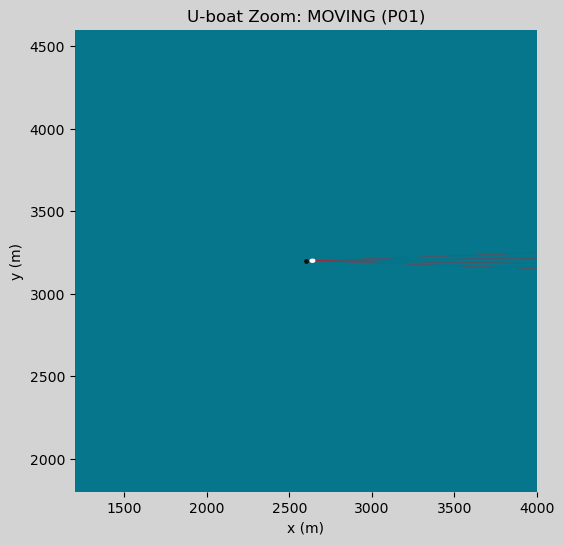

wrote /Users/matthewplambeck/Desktop/Convoy Layout Project/notebooks/results/attack_manual_verification/moving/uboat_zoom.png


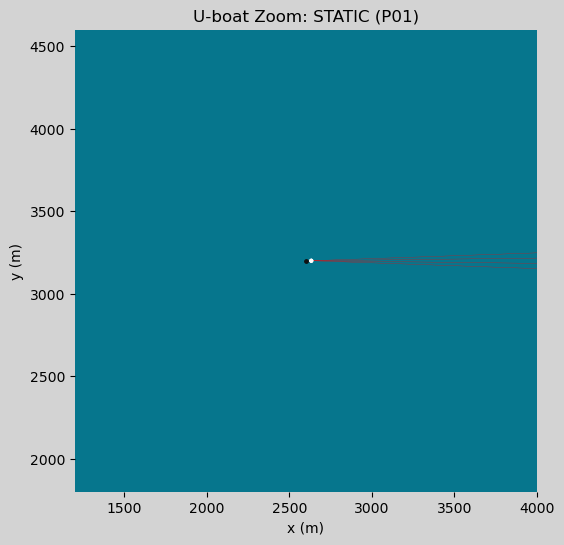

wrote /Users/matthewplambeck/Desktop/Convoy Layout Project/notebooks/results/attack_manual_verification/static/uboat_zoom.png


In [8]:
# --- Optional: U-boat Zoom (no ships) torpedo spread view ---
if importlib.util.find_spec('matplotlib') is None:
    raise RuntimeError('matplotlib is required for zoom plot.')

import matplotlib.pyplot as plt


def plot_uboat_zoom(label: str, data: dict, window_m: float = 1400.0):
    case_dir = OUTPUT_ROOT / label.lower()
    case_dir.mkdir(parents=True, exist_ok=True)

    u0 = np.asarray(data['launch_pos'], dtype=float)
    fig, ax = plt.subplots(figsize=(6, 6), facecolor='lightgrey')
    ax.set_facecolor('#06768d')

    # U-boat marker
    ax.scatter(u0[0], u0[1], s=float(U_BOAT_MARKER_SIZE), c='#111111', zorder=5, label='U-boat')

    # Draw first 120s torpedo track rays
    horizon_s = min(120.0, float(SIM_DURATION_S))
    for torp in data['torpedoes']:
        p0 = np.asarray(torp.launch_position, dtype=float)
        p1 = np.asarray(torp.position_at(horizon_s), dtype=float)
        ax.plot([p0[0], p1[0]], [p0[1], p1[1]], color='red', linewidth=float(TRAIL_LINEWIDTH), alpha=0.9)
        ax.scatter(p0[0], p0[1], s=8, c='white', edgecolors='none', zorder=6)

    ax.set_title(f'U-boat Zoom: {label.upper()} ({PROFILE_ID})')
    ax.set_xlabel('x (m)')
    ax.set_ylabel('y (m)')
    ax.set_xlim(u0[0] - window_m, u0[0] + window_m)
    ax.set_ylim(u0[1] - window_m, u0[1] + window_m)
    ax.set_aspect('equal', adjustable='box')
    for spine in ax.spines.values():
        spine.set_visible(False)

    out = case_dir / 'uboat_zoom.png'
    fig.savefig(out, dpi=150)
    plt.show()
    plt.close(fig)
    print('wrote', out)


plot_uboat_zoom('moving', moving)
plot_uboat_zoom('static', static)


In [9]:
# --- Pass/Fail Checks ---
move_dist = float(np.linalg.norm(moving['end_pos'] - moving['start_pos']))
static_dist = float(np.linalg.norm(static['end_pos'] - static['start_pos']))
launch_delta = float(np.linalg.norm(moving['launch_pos'] - static['launch_pos']))

print('move_dist_moving_m:', move_dist)
print('move_dist_static_m:', static_dist)
print('launch_pos_delta_moving_vs_static_m:', launch_delta)

assert move_dist > 0.0, 'FAIL: moving mode should have non-zero displacement.'
assert static_dist < 1e-9, 'FAIL: static mode displacement should be zero.'
assert launch_delta > 0.0 or moving_profile.u_boat_launch_time_s == 0.0, 'FAIL: expected different launch positions unless launch time is zero.'
assert len(moving['torpedoes']) > 0 and len(static['torpedoes']) > 0, 'FAIL: expected torpedoes in both modes.'

# Bow-fire constraint checks: torpedoes should not fire behind submarine heading.
for label, data in [('moving', moving), ('static', static)]:
    sub_h = float(data['launch_heading_rad'])
    for t in data['torpedoes']:
        delta = float(np.arctan2(np.sin(t.heading_rad - sub_h), np.cos(t.heading_rad - sub_h)))
        assert abs(delta) <= (np.pi / 2.0 + 1e-9), f'FAIL: {label}/{t.id} fires outside forward hemisphere.'

print('PASS: realism checks succeeded for moving vs static U-boat (including bow-fire constraint).')


move_dist_moving_m: 360.0
move_dist_static_m: 0.0
launch_pos_delta_moving_vs_static_m: 0.0
PASS: realism checks succeeded for moving vs static U-boat (including bow-fire constraint).


## Environment Notes

In current code, environment (`time_of_day`, `visibility_m`, `sea_state`, `detection_risk_scale`) affects:
- attacker-side context/observation fields and proposal feasibility/risk context
- diagnostic metadata and realism conditioning

It does **not** currently change torpedo-ship hit physics directly (hit geometry remains kinematic).
